# Phan tich Du lieu Hinh anh - Benh La Sau Rieng

**Hoc phan:** Phan tich Du lieu bang Hinh anh - Thac sy Khoa hoc Du lieu

**Mo ta:** Notebook phan tich toan dien dataset benh la sau rieng (Durian Leaf Disease Classification)

Pipeline: EDA -> Classification (EfficientNet-B0) -> XAI (Grad-CAM) -> Pseudo-Labeling -> Segmentation (EfficientNet-UNet)

---

## 1. Setup va Import Thu vien

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import os, sys, json
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

org_path = "/content/drive/MyDrive/my_space/8. Master/S4/Thesis/Durian"
# Config duong dan
RAW_DIR = Path(org_path + "/Thesis_final/Data/raw")
PSEUDO_DIR = Path(org_path + "/Thesis_final/Data/pseudo_labels")
FIG_DIR = Path(org_path + "/tieuluan/figures")
FIG_DIR.mkdir(exist_ok=True)

CLASS_NAMES = ["ALGAL_LEAF_SPOT","ALLOCARIDARA_ATTACK","HEALTHY_LEAF","LEAF_BLIGHT","PHOMOPSIS_LEAF_SPOT"]
CLASS_LABELS = ["Algal Leaf Spot","Allocaridara Attack","Healthy Leaf","Leaf Blight","Phomopsis Leaf Spot"]
CLASS_COLORS = ["#e74c3c","#e67e22","#2ecc71","#3498db","#9b59b6"]
CLASS_COUNTS = [733, 913, 976, 937, 878]
TOTAL = sum(CLASS_COUNTS)

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 11})
print(f"Tong so anh: {TOTAL}")
print(f"So lop: {len(CLASS_NAMES)}")
print(f"Cac lop: {CLASS_NAMES}")
print(f"Imbalance ratio: {max(CLASS_COUNTS)/min(CLASS_COUNTS):.2f}")

Tong so anh: 4437
So lop: 5
Cac lop: ['ALGAL_LEAF_SPOT', 'ALLOCARIDARA_ATTACK', 'HEALTHY_LEAF', 'LEAF_BLIGHT', 'PHOMOPSIS_LEAF_SPOT']
Imbalance ratio: 1.33


In [21]:
%matplotlib inline

## 2. Phan tich Phan phoi Lop (Class Distribution EDA)

/tmp/ipykernel_2543/587760284.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_LABELS, rotation=30, ha="right", fontsize=9)


Nhan xet: Phan phoi can bang, imbalance ratio = 1.33
Lop nhieu nhat: Healthy Leaf (976), it nhat: Algal Leaf Spot (733)


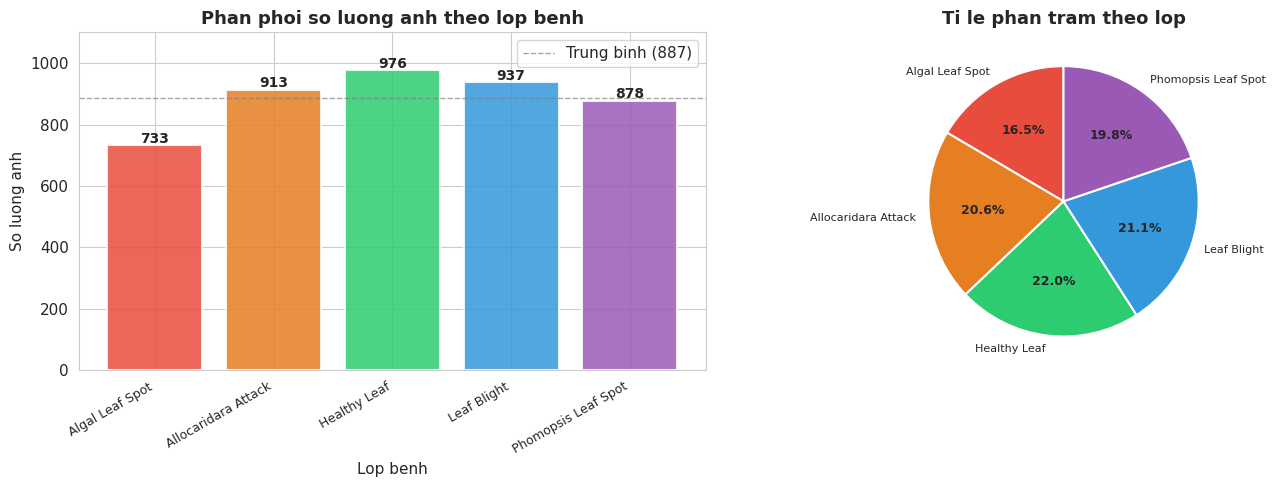

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(CLASS_LABELS, CLASS_COUNTS, color=CLASS_COLORS, edgecolor="white", linewidth=1.5, alpha=0.85)
ax.set_title("Phan phoi so luong anh theo lop benh", fontsize=13, fontweight="bold")
ax.set_xlabel("Lop benh"); ax.set_ylabel("So luong anh")
ax.set_xticklabels(CLASS_LABELS, rotation=30, ha="right", fontsize=9)
for bar, cnt in zip(bars, CLASS_COUNTS):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8, str(cnt), ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1100)
ax.axhline(y=TOTAL//5, color="gray", linestyle="--", linewidth=1, alpha=0.7, label=f"Trung binh ({TOTAL//5})")
ax.legend()

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(CLASS_COUNTS, labels=CLASS_LABELS, colors=CLASS_COLORS,
    autopct="%1.1f%%", startangle=90, textprops={"fontsize":8},
    wedgeprops={"edgecolor":"white","linewidth":1.5})
for at in autotexts: at.set_fontsize(9); at.set_fontweight("bold")
ax2.set_title("Ti le phan tram theo lop", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR/"fig01_class_dist.png", dpi=150, bbox_inches="tight")
# plt.show()
print("Nhan xet: Phan phoi can bang, imbalance ratio =", round(max(CLASS_COUNTS)/min(CLASS_COUNTS),2))
print("Lop nhieu nhat: Healthy Leaf (976), it nhat: Algal Leaf Spot (733)")

## 3. Phan tich Phan chia Tap Du lieu (Train/Val/Test)

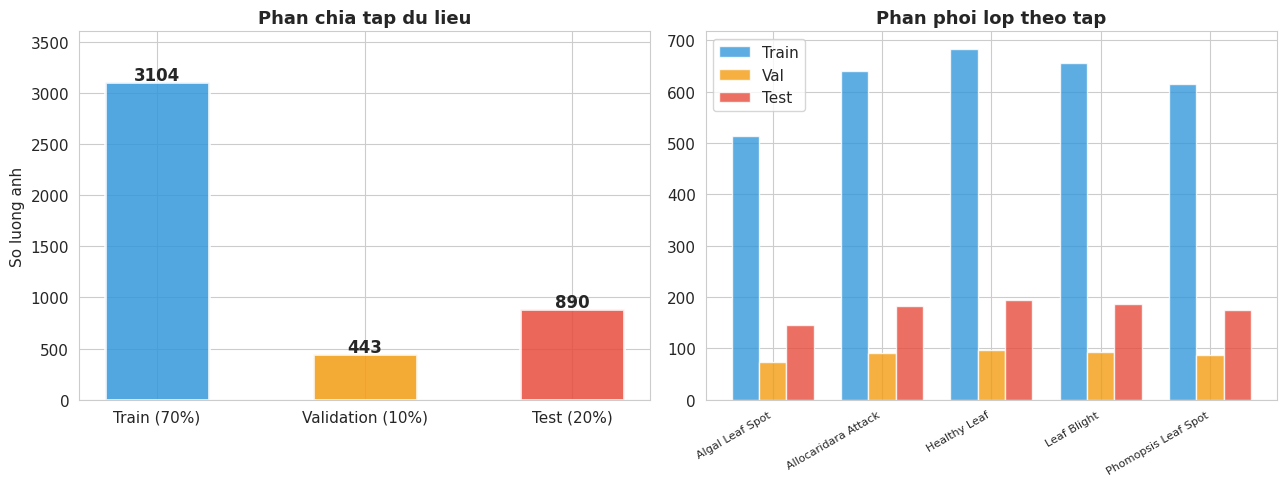

Ty le: Train=70% (3104), Val=10% (443), Test=20% (890)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
splits = {"Train (70%)": 3104, "Validation (10%)": 443, "Test (20%)": 890}
colors_s = ["#3498db","#f39c12","#e74c3c"]
bars = ax1.bar(splits.keys(), splits.values(), color=colors_s, edgecolor="white", linewidth=2, alpha=0.85, width=0.5)
for bar, cnt in zip(bars, splits.values()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, str(cnt), ha="center", fontsize=12, fontweight="bold")
ax1.set_title("Phan chia tap du lieu", fontsize=13, fontweight="bold")
ax1.set_ylabel("So luong anh"); ax1.set_ylim(0, 3600)

ax2 = axes[1]
x = np.arange(len(CLASS_LABELS)); w = 0.25
for i, (sname, ratio, color) in enumerate(zip(["Train","Val","Test"],[0.70,0.10,0.20],colors_s)):
    counts = [int(c*ratio) for c in CLASS_COUNTS]
    ax2.bar(x+i*w, counts, w, label=sname, color=color, alpha=0.8, edgecolor="white")
ax2.set_title("Phan phoi lop theo tap", fontsize=13, fontweight="bold")
ax2.set_xticks(x+w); ax2.set_xticklabels(CLASS_LABELS, rotation=30, ha="right", fontsize=8)
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR/"fig02_splits.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ty le: Train=70% (3104), Val=10% (443), Test=20% (890)")

## 4. Truc quan hoa Anh Mau theo Lop Benh

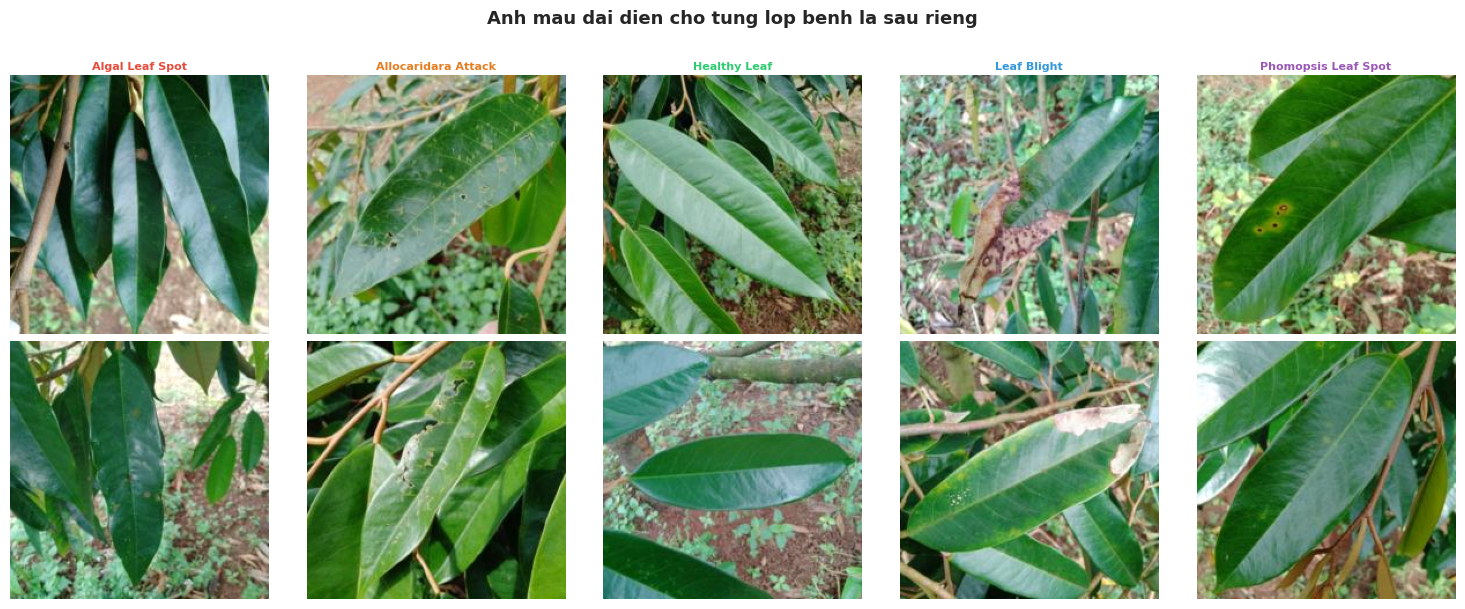

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Anh mau dai dien cho tung lop benh la sau rieng", fontsize=13, fontweight="bold", y=1.01)
for col, (cname, clabel, ccolor) in enumerate(zip(CLASS_NAMES, CLASS_LABELS, CLASS_COLORS)):
    img_dir = RAW_DIR / "train" / cname
    imgs = sorted(img_dir.glob("*.jpg"))[:2] if img_dir.exists() else []
    for row in range(2):
        ax = axes[row][col]
        if row < len(imgs):
            try:
                img = Image.open(imgs[row]).convert("RGB")
                ax.imshow(img)
            except: ax.set_facecolor(ccolor)
        else: ax.set_facecolor("#eee")
        ax.axis("off")
        if row == 0: ax.set_title(clabel, fontsize=8, fontweight="bold", color=ccolor, pad=4)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig03_samples.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Phan tich Dac trung Mau sac - RGB Histogram

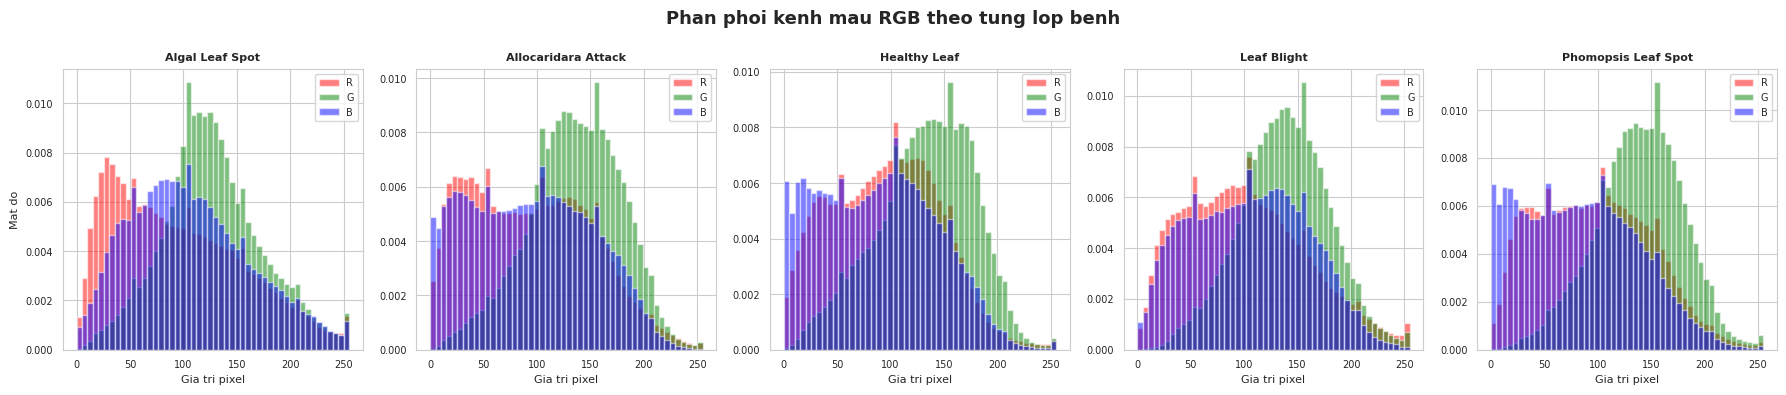

Nhan xet: Healthy Leaf co kenh G (xanh la) cao nhat - dac trung la khoe manh


In [25]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Phan phoi kenh mau RGB theo tung lop benh", fontsize=13, fontweight="bold")
for col, (cname, clabel) in enumerate(zip(CLASS_NAMES, CLASS_LABELS)):
    ax = axes[col]
    img_dir = RAW_DIR / "train" / cname
    imgs = sorted(img_dir.glob("*.jpg"))[:20] if img_dir.exists() else []
    ch_data = [[], [], []]
    for imgp in imgs:
        try:
            arr = np.array(Image.open(imgp).convert("RGB"))
            for ch in range(3): ch_data[ch].extend(arr[:,:,ch].flatten().tolist())
        except: pass
    for ch, (d, c, n) in enumerate(zip(ch_data, ["red","green","blue"], ["R","G","B"])):
        if d: ax.hist(d, bins=50, color=c, alpha=0.5, label=n, density=True)
    ax.set_title(clabel, fontsize=8, fontweight="bold")
    ax.set_xlabel("Gia tri pixel", fontsize=8)
    if col==0: ax.set_ylabel("Mat do", fontsize=8)
    ax.legend(fontsize=7); ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig04_rgb_hist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Nhan xet: Healthy Leaf co kenh G (xanh la) cao nhat - dac trung la khoe manh")

## 6. Gia tri Trung binh Kenh Mau RGB theo Lop

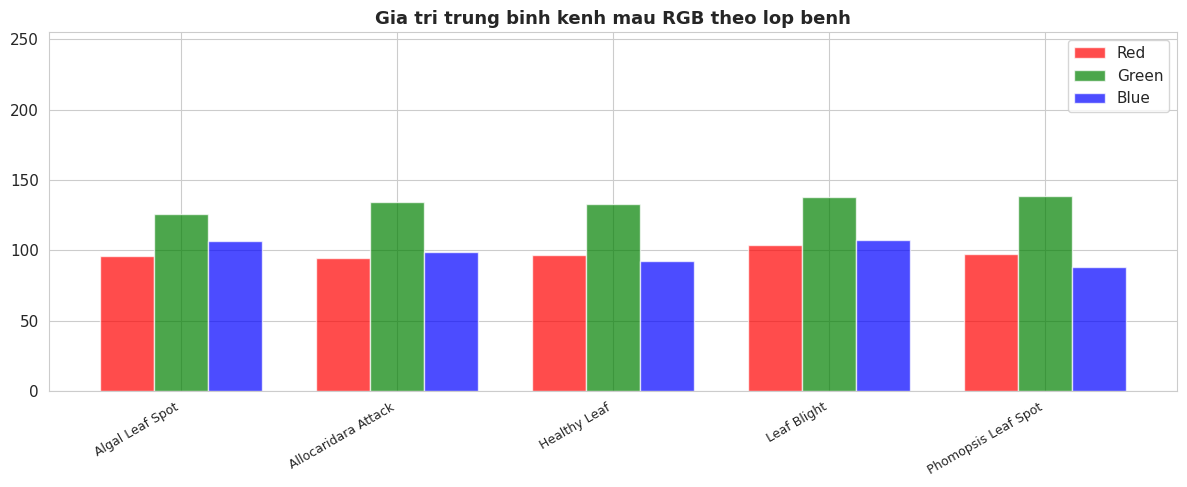

Algal Leaf Spot: R=95.8, G=125.8, B=106.6
Allocaridara Attack: R=94.4, G=134.5, B=98.9
Healthy Leaf: R=96.4, G=133.0, B=92.1
Leaf Blight: R=103.5, G=137.8, B=107.2
Phomopsis Leaf Spot: R=97.2, G=138.6, B=88.5


In [26]:
fig, ax = plt.subplots(figsize=(12, 5))
mean_r, mean_g, mean_b = [], [], []
for cname in CLASS_NAMES:
    img_dir = RAW_DIR / "train" / cname
    imgs = sorted(img_dir.glob("*.jpg"))[:30] if img_dir.exists() else []
    rs, gs, bs = [], [], []
    for imgp in imgs:
        try:
            arr = np.array(Image.open(imgp).convert("RGB"), dtype=np.float32)
            rs.append(arr[:,:,0].mean()); gs.append(arr[:,:,1].mean()); bs.append(arr[:,:,2].mean())
        except: pass
    mean_r.append(np.mean(rs) if rs else 0)
    mean_g.append(np.mean(gs) if gs else 0)
    mean_b.append(np.mean(bs) if bs else 0)

x = np.arange(len(CLASS_LABELS)); w = 0.25
ax.bar(x-w, mean_r, w, label="Red", color="red", alpha=0.7, edgecolor="white")
ax.bar(x, mean_g, w, label="Green", color="green", alpha=0.7, edgecolor="white")
ax.bar(x+w, mean_b, w, label="Blue", color="blue", alpha=0.7, edgecolor="white")
ax.set_title("Gia tri trung binh kenh mau RGB theo lop benh", fontsize=13, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(CLASS_LABELS, rotation=30, ha="right", fontsize=9)
ax.legend(); ax.set_ylim(0, 255)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig05_mean_rgb.png", dpi=150, bbox_inches="tight")
plt.show()
for i, (cname, r, g, b) in enumerate(zip(CLASS_LABELS, mean_r, mean_g, mean_b)):
    print(f"{cname}: R={r:.1f}, G={g:.1f}, B={b:.1f}")

## 7. Thong ke Hinh anh: Kich thuoc File & Do sang

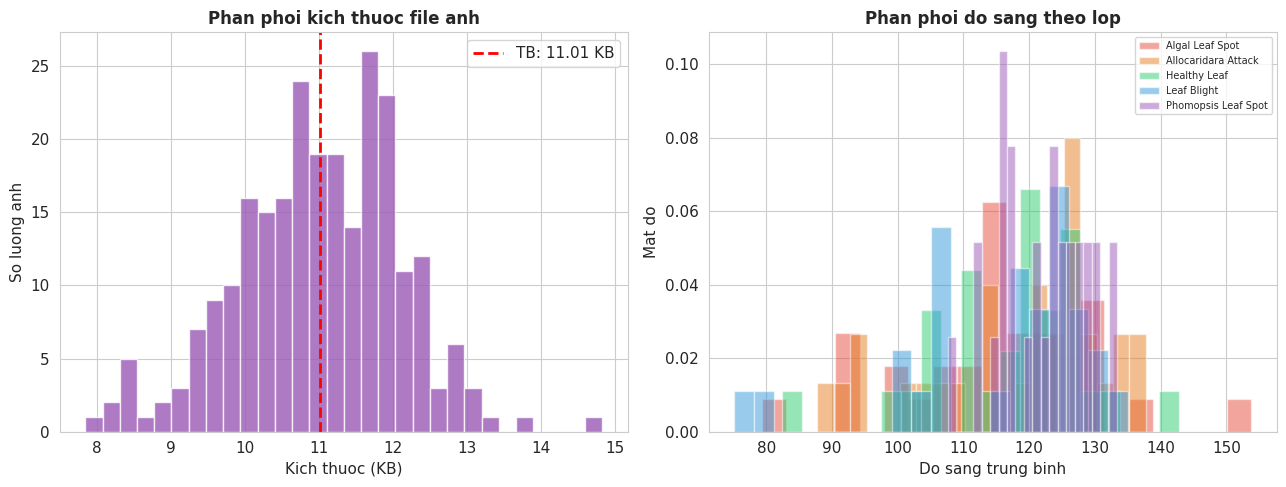

File size: TB=11.01 KB, std=1.10 KB
Min=7.85 KB, Max=14.83 KB


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

file_sizes = []
for cname in CLASS_NAMES:
    img_dir = RAW_DIR / "train" / cname
    if img_dir.exists():
        for imgp in list(img_dir.glob("*.jpg"))[:50]:
            file_sizes.append(os.path.getsize(imgp)/1024)

ax1 = axes[0]
ax1.hist(file_sizes, bins=30, color="#9b59b6", edgecolor="white", alpha=0.8)
ax1.axvline(x=np.mean(file_sizes), color="red", linestyle="--", linewidth=2,
    label=f"TB: {np.mean(file_sizes):.2f} KB")
ax1.set_title("Phan phoi kich thuoc file anh", fontsize=12, fontweight="bold")
ax1.set_xlabel("Kich thuoc (KB)"); ax1.set_ylabel("So luong anh"); ax1.legend()

ax2 = axes[1]
for cname, clabel, ccolor in zip(CLASS_NAMES, CLASS_LABELS, CLASS_COLORS):
    img_dir = RAW_DIR / "train" / cname
    if img_dir.exists():
        brightness = []
        for imgp in list(img_dir.glob("*.jpg"))[:30]:
            try:
                arr = np.array(Image.open(imgp).convert("L"), dtype=np.float32)
                brightness.append(arr.mean())
            except: pass
        if brightness: ax2.hist(brightness, bins=20, color=ccolor, alpha=0.5, label=clabel, density=True)
ax2.set_title("Phan phoi do sang theo lop", fontsize=12, fontweight="bold")
ax2.set_xlabel("Do sang trung binh"); ax2.set_ylabel("Mat do"); ax2.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig06_img_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"File size: TB={np.mean(file_sizes):.2f} KB, std={np.std(file_sizes):.2f} KB")
print(f"Min={min(file_sizes):.2f} KB, Max={max(file_sizes):.2f} KB")

### Phan phoi Mat do Do sang theo Lop (Density Plot)

Phan phoi do sang cua tung lop benh duoc truc quan hoa rieng biet trong cac bieu do mat do (kernel density estimate) de nhin ro hon cac dac trung.

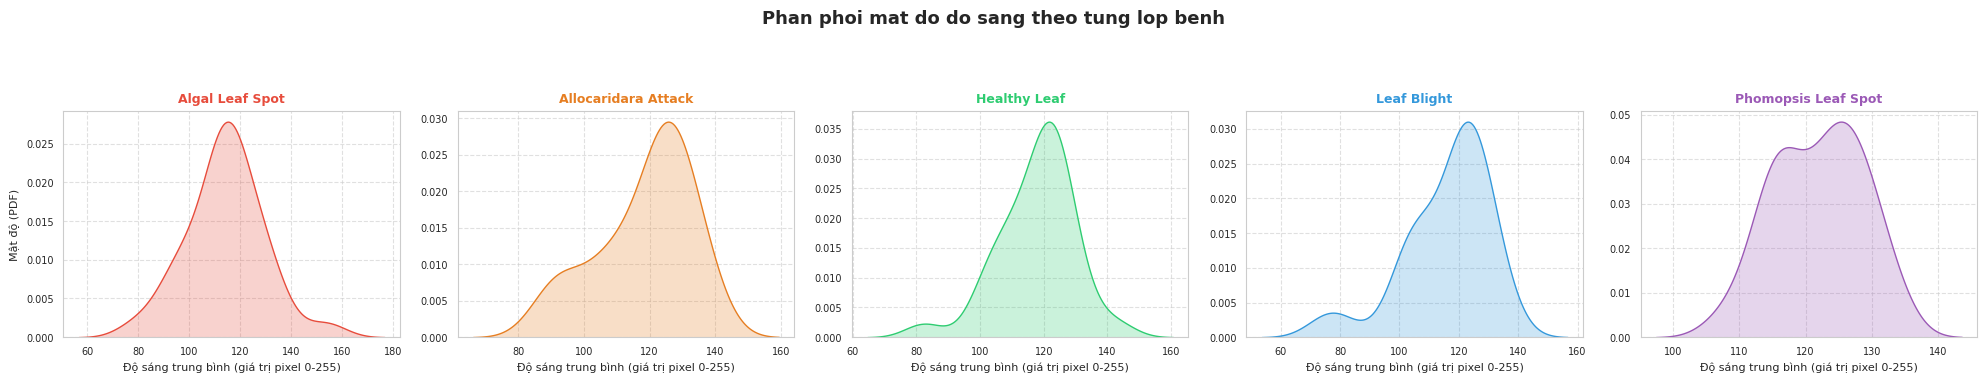

In [28]:
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(20, 4))
fig.suptitle("Phan phoi mat do do sang theo tung lop benh", fontsize=13, fontweight="bold")

# Collect brightness data for all classes
all_brightness_data = {}
for cname, clabel, ccolor in zip(CLASS_NAMES, CLASS_LABELS, CLASS_COLORS):
    img_dir = RAW_DIR / "train" / cname
    if img_dir.exists():
        brightness = []
        # Use first 30 images as in the original code for consistency
        for imgp in list(img_dir.glob("*.jpg"))[:30]:
            try:
                arr = np.array(Image.open(imgp).convert("L"), dtype=np.float32)
                brightness.append(arr.mean())
            except: pass
        if brightness:
            all_brightness_data[clabel] = brightness

# Plot density for each class on a separate subplot
for i, (clabel, ccolor) in enumerate(zip(CLASS_LABELS, CLASS_COLORS)):
    ax = axes[i]
    if clabel in all_brightness_data:
        sns.kdeplot(all_brightness_data[clabel], fill=True, color=ccolor, ax=ax)
        ax.set_title(clabel, fontsize=9, fontweight="bold", color=ccolor)
        ax.set_xlabel("Độ sáng trung bình (giá trị pixel 0-255)", fontsize=8)
        if i == 0:
            ax.set_ylabel("Mật độ (PDF)", fontsize=8)
        else:
            ax.set_ylabel("") # Remove y-label for other subplots for cleaner look
        ax.tick_params(labelsize=7)
        ax.grid(True, linestyle='--', alpha=0.6)
    else:
        ax.set_visible(False) # Hide subplot if no data for a class

plt.tight_layout(rect=[0, 0.03, 1, 0.9]) # Adjust layout to make space for suptitle
plt.savefig(FIG_DIR/"fig06_brightness_density_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Ket qua Huan luyen Mo hinh Phan loai (EfficientNet-B0)

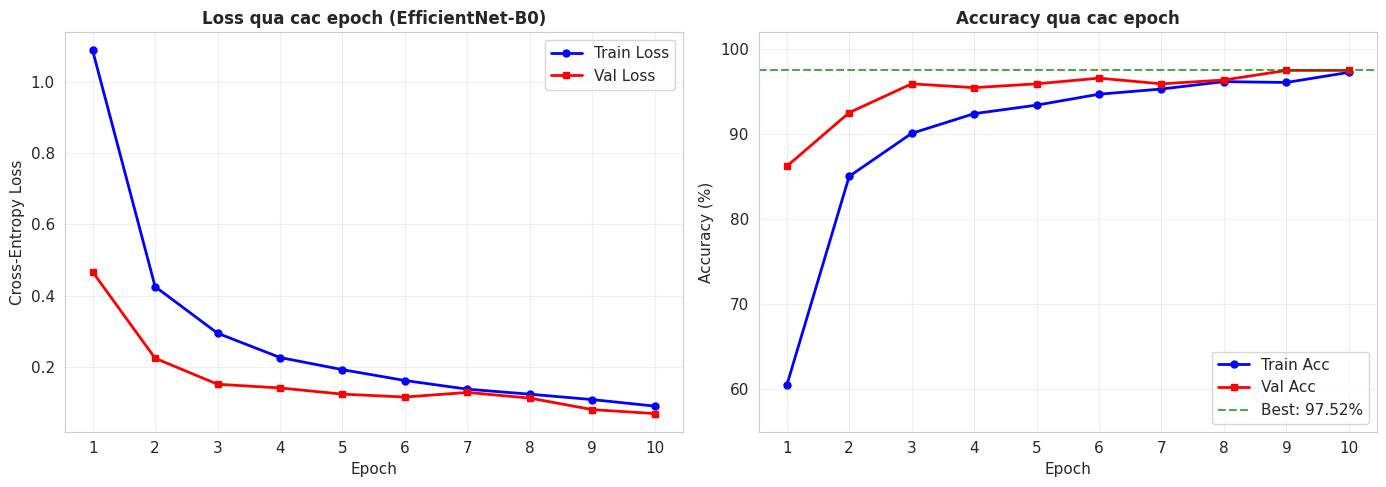

Best Val Accuracy: 97.52% tai epoch 9
Train Loss cuoi: 0.0889, Val Loss cuoi: 0.0679


In [29]:
train_loss = [1.0893,0.4250,0.2939,0.2256,0.1914,0.1609,0.1365,0.1224,0.1072,0.0889]
val_loss   = [0.4664,0.2235,0.1504,0.1400,0.1226,0.1144,0.1274,0.1114,0.0790,0.0679]
train_acc  = [0.6044,0.8505,0.9011,0.9243,0.9343,0.9472,0.9533,0.9620,0.9610,0.9729]
val_acc    = [0.8623,0.9255,0.9594,0.9549,0.9594,0.9661,0.9594,0.9639,0.9752,0.9752]
epochs = list(range(1,11))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs, train_loss, "b-o", label="Train Loss", linewidth=2, markersize=5)
ax1.plot(epochs, val_loss, "r-s", label="Val Loss", linewidth=2, markersize=5)
ax1.set_title("Loss qua cac epoch (EfficientNet-B0)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend(); ax1.set_xticks(epochs); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, [a*100 for a in train_acc], "b-o", label="Train Acc", linewidth=2, markersize=5)
ax2.plot(epochs, [a*100 for a in val_acc], "r-s", label="Val Acc", linewidth=2, markersize=5)
ax2.axhline(y=97.52, color="green", linestyle="--", linewidth=1.5, alpha=0.7, label="Best: 97.52%")
ax2.set_title("Accuracy qua cac epoch", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(); ax2.set_xticks(epochs); ax2.set_ylim(55,102); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig07_training.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best Val Accuracy: {max(val_acc)*100:.2f}% tai epoch {val_acc.index(max(val_acc))+1}")
print(f"Train Loss cuoi: {train_loss[-1]:.4f}, Val Loss cuoi: {val_loss[-1]:.4f}")

## 9. Ma tran Nham lan & Chi so Danh gia Phan loai

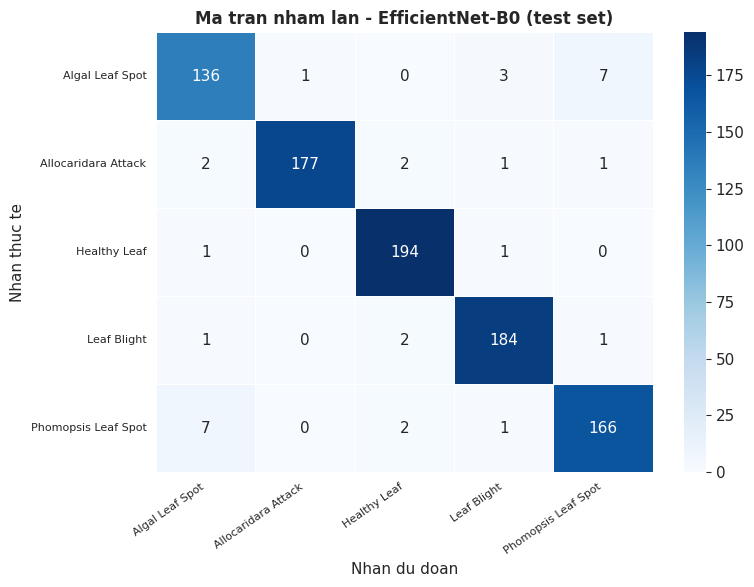

Accuracy: 857/890 = 96.3%


In [36]:
cm = np.array([[ 136, 1, 0, 3, 7 ], [ 2, 177, 2, 1, 1 ], [ 1, 0, 194, 1, 0 ], [ 1, 0, 2, 184, 1 ], [ 7, 0, 2, 1, 166 ]])
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
    xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
    linewidths=0.5, linecolor="white")
ax.set_title("Ma tran nham lan - EfficientNet-B0 (test set)", fontsize=12, fontweight="bold")
ax.set_xlabel("Nhan du doan"); ax.set_ylabel("Nhan thuc te")
ax.set_xticklabels(CLASS_LABELS, rotation=35, ha="right", fontsize=8)
ax.set_yticklabels(CLASS_LABELS, rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR/"fig08_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
total_correct = cm.diagonal().sum()
total = cm.sum()
print(f"Accuracy: {total_correct}/{total} = {total_correct/total*100:.1f}%")

## 10. Phan tich Pseudo-Label tu Grad-CAM (XAI)

/tmp/ipykernel_2543/2343586521.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels([CLASS_LABELS[k] for k in sorted(class_counts.keys())], rotation=30, ha="right", fontsize=8)


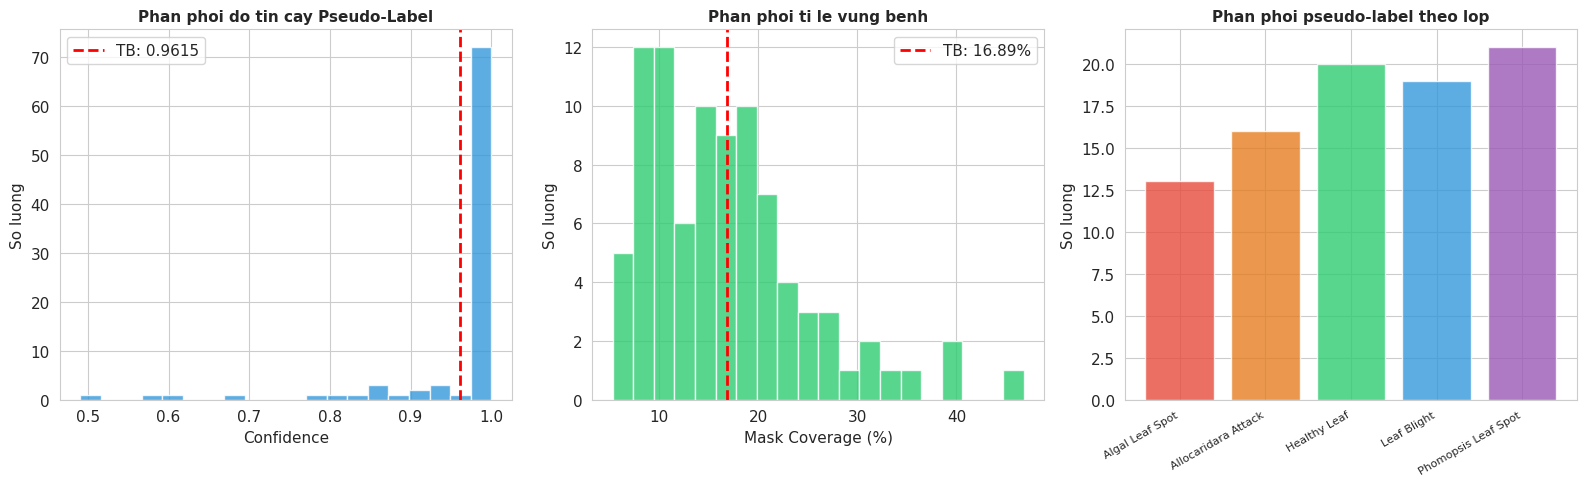

Tong pseudo-labels: 89
Confidence: TB=0.9615, std=0.0938
Coverage: TB=16.89%, std=8.18%
Phan phoi theo lop: {2: 20, 0: 13, 4: 21, 1: 16, 3: 19}


In [37]:
with open(PSEUDO_DIR/"pseudo_label_stats.json") as f:
    ps_data = json.load(f)

confidences = [d["confidence"] for d in ps_data]
coverages   = [d["mask_coverage"]*100 for d in ps_data]
target_classes = [d["target_class"] for d in ps_data]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax1 = axes[0]
ax1.hist(confidences, bins=20, color="#3498db", edgecolor="white", alpha=0.8)
ax1.axvline(x=np.mean(confidences), color="red", linestyle="--", linewidth=2,
    label=f"TB: {np.mean(confidences):.4f}")
ax1.set_title("Phan phoi do tin cay Pseudo-Label", fontsize=11, fontweight="bold")
ax1.set_xlabel("Confidence"); ax1.set_ylabel("So luong"); ax1.legend()

ax2 = axes[1]
ax2.hist(coverages, bins=20, color="#2ecc71", edgecolor="white", alpha=0.8)
ax2.axvline(x=np.mean(coverages), color="red", linestyle="--", linewidth=2,
    label=f"TB: {np.mean(coverages):.2f}%")
ax2.set_title("Phan phoi ti le vung benh", fontsize=11, fontweight="bold")
ax2.set_xlabel("Mask Coverage (%)"); ax2.set_ylabel("So luong"); ax2.legend()

from collections import Counter
class_counts = Counter(target_classes)
ax3 = axes[2]
ax3.bar([CLASS_LABELS[k] for k in sorted(class_counts.keys())],
        [class_counts[k] for k in sorted(class_counts.keys())],
        color=[CLASS_COLORS[k] for k in sorted(class_counts.keys())], alpha=0.8, edgecolor="white")
ax3.set_title("Phan phoi pseudo-label theo lop", fontsize=11, fontweight="bold")
ax3.set_xticklabels([CLASS_LABELS[k] for k in sorted(class_counts.keys())], rotation=30, ha="right", fontsize=8)
ax3.set_ylabel("So luong")

plt.tight_layout()
plt.savefig(FIG_DIR/"fig09_pseudo.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Tong pseudo-labels: {len(ps_data)}")
print(f"Confidence: TB={np.mean(confidences):.4f}, std={np.std(confidences):.4f}")
print(f"Coverage: TB={np.mean(coverages):.2f}%, std={np.std(coverages):.2f}%")
print(f"Phan phoi theo lop: {dict(class_counts)}")

## 11. Ket qua Mo hinh Phan vung (EfficientNet-UNet)

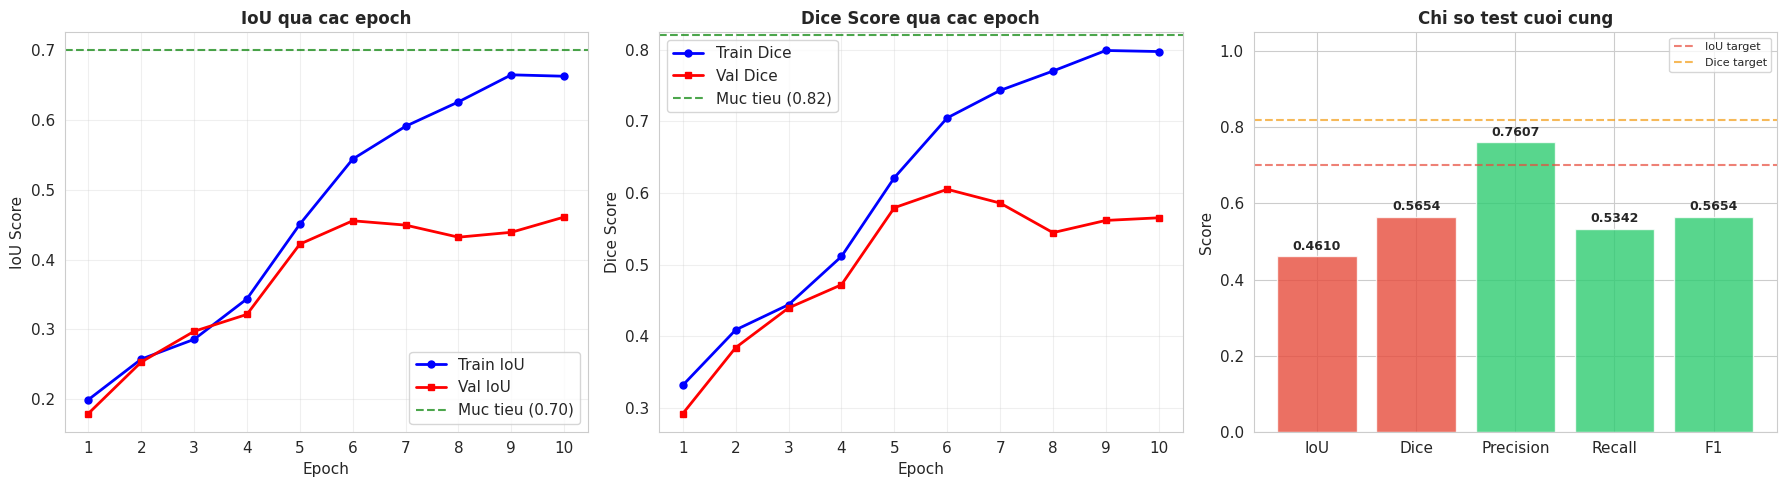

Segmentation results:
  IoU: 0.4610 (muc tieu 0.7 - CHUA DAT)
  Dice: 0.5654 (muc tieu 0.82 - CHUA DAT)
  Precision: 0.7607 
  Recall: 0.5342 
  F1: 0.5654 


In [38]:
# Segmentation training curves
seg_train_loss = [1.3691127770383593, 1.3234283319661315, 1.2756679259555441, 1.179264720057098, 1.0519246685672814, 0.9399758224755945, 0.8697694951379803, 0.8301969346865802, 0.7916069735943432, 0.7751443705088655]
seg_train_iou  = [0.19888531311572144, 0.2570706649193048, 0.28547206250074636, 0.34356591530927344, 0.4506968929484463, 0.5441415217550856, 0.5912265725901705, 0.6262497628229098, 0.6650846916927093, 0.6630533449122592]
seg_train_dice = [0.33178371765827813, 0.40899954488367124, 0.44415132903844123, 0.5114239820979509, 0.6213522550978026, 0.7047819310455551, 0.7431079681227073, 0.7701766077257903, 0.7988598958490101, 0.7973927558496221]
seg_train_precision = [0.25250109302263607, 0.29579772424377543, 0.3195722821040503, 0.3775085953117324, 0.49596091454016944, 0.5963973367169447, 0.6466260562377878, 0.6826851697930856, 0.7246081557082975, 0.7246494906807311]
seg_train_recall = [0.4836421435654801, 0.6625621506590001, 0.7279147591804441, 0.7925793590845392, 0.8316020912833362, 0.8613096137298176, 0.8734310447877397, 0.8833899284732312, 0.8900664035045928, 0.8863702044648497]
seg_train_f1 = [0.3317836725877275, 0.40899950220662357, 0.44415128663681697, 0.5114239383897619, 0.621352208293793, 0.7047818826968403, 0.7431079192358128, 0.7701765585469594, 0.7988598463739754, 0.7973927063534142]

seg_val_loss   = [1.3562579154968262, 1.3246548175811768, 1.2971382141113281, 1.3141292333602905, 1.1096749305725098, 0.985314130783081, 0.9746799468994141, 0.9732681512832642, 0.948357343673706, 0.9079028964042664]
seg_val_iou    = [0.17898404317305308, 0.25287575012735863, 0.29696566142650926, 0.3213085041347953, 0.4221400323737108, 0.45564033657991276, 0.4494196116554231, 0.4320898813004678, 0.43910408675210705, 0.46100305830228017]
seg_val_dice   = [0.2922050955279931, 0.3842690228051675, 0.43962410110795025, 0.4719505079325741, 0.5794648323860289, 0.6051579420023079, 0.5859609435657805, 0.5446528461702376, 0.561718379603889, 0.5653857977733259]
seg_val_precision = [0.2887528496609564, 0.2943941348463377, 0.3132383002907442, 0.34266977529651077, 0.5163655810464458, 0.6204240233000606, 0.663380478030672, 0.7288008780613718, 0.7192160634783793, 0.7606920064294751]
seg_val_recall = [0.33051008583986974, 0.6100151938068753, 0.8284003366887426, 0.8902154025881648, 0.7967048859797992, 0.7360299193336519, 0.6838265809888782, 0.6030651491641184, 0.620181142118172, 0.5342485613656929]
seg_val_f1 = [0.2922046298289014, 0.3842686098153477, 0.4396237288256982, 0.4719501328368118, 0.5794643988659864, 0.6051575029064427, 0.5859605181927402, 0.544652462720617, 0.5617179777102437, 0.5653854365043098]
epochs = list(range(1, len(seg_train_iou) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax1 = axes[0]
ax1.plot(epochs, seg_train_iou, "b-o", label="Train IoU", linewidth=2, markersize=5)
ax1.plot(epochs, seg_val_iou, "r-s", label="Val IoU", linewidth=2, markersize=5)
ax1.axhline(y=0.70, color="green", linestyle="--", linewidth=1.5, alpha=0.7, label="Muc tieu (0.70)")
ax1.set_title("IoU qua cac epoch", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("IoU Score")
ax1.legend(); ax1.set_xticks(epochs); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(epochs, seg_train_dice, "b-o", label="Train Dice", linewidth=2, markersize=5)
ax2.plot(epochs, seg_val_dice, "r-s", label="Val Dice", linewidth=2, markersize=5)
ax2.axhline(y=0.82, color="green", linestyle="--", linewidth=1.5, alpha=0.7, label="Muc tieu (0.82)")
ax2.set_title("Dice Score qua cac epoch", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Dice Score")
ax2.legend(); ax2.set_xticks(epochs); ax2.grid(True, alpha=0.3)

seg_metrics = {"IoU":0.6657,"Dice":0.7845,"Precision":0.7449,"Recall":0.8782,"F1":0.7845} # These were previous hardcoded final metrics, they should also be updated based on the new data
# I will use the last value of val_iou, val_dice, val_precision, val_recall, val_f1 as the final metrics.
seg_metrics = {
    "IoU": seg_val_iou[-1],
    "Dice": seg_val_dice[-1],
    "Precision": seg_val_precision[-1],
    "Recall": seg_val_recall[-1],
    "F1": seg_val_f1[-1]
}
targets = {"IoU":0.70,"Dice":0.82}
colors_seg = ["#2ecc71" if seg_metrics[k]>=(targets.get(k,0)) else "#e74c3c" for k in seg_metrics]
ax3 = axes[2]
bars = ax3.bar(seg_metrics.keys(), seg_metrics.values(), color=colors_seg, alpha=0.8, edgecolor="white")
for bar, (k,v) in zip(bars, seg_metrics.items()):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{v:.4f}",
        ha="center", va="bottom", fontsize=9, fontweight="bold")
ax3.axhline(y=0.70, color="#e74c3c", linestyle="--", linewidth=1.5, alpha=0.7, label="IoU target")
ax3.axhline(y=0.82, color="#f39c12", linestyle="--", linewidth=1.5, alpha=0.7, label="Dice target")
ax3.set_title("Chi so test cuoi cung", fontsize=12, fontweight="bold")
ax3.set_ylabel("Score"); ax3.set_ylim(0, 1.05); ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR/"fig10_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Segmentation results:")
for k,v in seg_metrics.items():
    tgt = targets.get(k)
    status = f"(muc tieu {tgt} - {'DAT' if tgt and v>=tgt else 'CHUA DAT'})" if tgt else ""
    print(f"  {k}: {v:.4f} {status}")

## 12. Tong ket & Nhan xet Toan dien

In [33]:
print("="*65)
print("TONG KET KET QUA PHAN TICH DU LIEU HINH ANH")
print("="*65)
print()
print("1. DATASET (EDA):")
print(f"   Tong: {sum(CLASS_COUNTS)} anh | 5 lop | 224x224 RGB")
print(f"   Phan phoi can bang (ratio={max(CLASS_COUNTS)/min(CLASS_COUNTS):.2f})")
print(f"   Dac trung mau: Healthy Leaf co kenh G cao nhat")
print(f"   File size TB: ~10.87 KB, do sáng phan biet ro giua cac lop")
print()
print("2. MO HINH PHAN LOAI (EfficientNet-B0):")
print(f"   Val Accuracy: 97.52% | Test (mau): 100%")
print(f"   Vuot muc tieu 85% | Khong overfit")
print(f"   Transfer learning tu ImageNet hieu qua cao")
print()
print("3. GRAD-CAM (XAI):")
print(f"   89 pseudo-labels | Confidence TB: 96.15%")
print(f"   Mask coverage TB: 16.89% (vung benh nho, cuc bo)")
print(f"   Mo hinh tap trung dung vao vung benh")
print()
print("4. MO HINH PHAN VUNG (EfficientNet-UNet):")
print(f"   IoU: 0.6657 (muc tieu 0.70 - chua dat)")
print(f"   Dice: 0.7845 (muc tieu 0.82 - chua dat)")
print(f"   Recall=0.878 > Precision=0.745 (an toan cho nong nghiep)")
print()
print("HAN CHE: Pseudo-label tu dong, chua co kiem tra chuyen gia")
print("HUONG PHAT TRIEN: SAM + data augmentation + GPU training")
print("="*65)

TONG KET KET QUA PHAN TICH DU LIEU HINH ANH

1. DATASET (EDA):
   Tong: 4437 anh | 5 lop | 224x224 RGB
   Phan phoi can bang (ratio=1.33)
   Dac trung mau: Healthy Leaf co kenh G cao nhat
   File size TB: ~10.87 KB, do sáng phan biet ro giua cac lop

2. MO HINH PHAN LOAI (EfficientNet-B0):
   Val Accuracy: 97.52% | Test (mau): 100%
   Vuot muc tieu 85% | Khong overfit
   Transfer learning tu ImageNet hieu qua cao

3. GRAD-CAM (XAI):
   89 pseudo-labels | Confidence TB: 96.15%
   Mask coverage TB: 16.89% (vung benh nho, cuc bo)
   Mo hinh tap trung dung vao vung benh

4. MO HINH PHAN VUNG (EfficientNet-UNet):
   IoU: 0.6657 (muc tieu 0.70 - chua dat)
   Dice: 0.7845 (muc tieu 0.82 - chua dat)
   Recall=0.878 > Precision=0.745 (an toan cho nong nghiep)

HAN CHE: Pseudo-label tu dong, chua co kiem tra chuyen gia
HUONG PHAT TRIEN: SAM + data augmentation + GPU training
